In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

PROCESSED = Path("../data/processed")
RAW       = Path("../data/raw")
REPORTS   = Path("../reports")
REPORTS.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"]     = 100

print("Libraries loaded!")
print(f"PROCESSED : {PROCESSED}")
print(f"RAW       : {RAW}")
print(f"REPORTS   : {REPORTS}")

Libraries loaded!
PROCESSED : ..\data\processed
RAW       : ..\data\raw
REPORTS   : ..\reports


In [3]:
df_fund = pd.read_csv(PROCESSED / "clean_fund_master.csv")

df_nav  = pd.read_csv(PROCESSED / "clean_nav_history.csv",
                      parse_dates=["date"])

df_aum  = pd.read_csv(PROCESSED / "clean_aum_by_fund_house.csv")

df_sip  = pd.read_csv(PROCESSED / "clean_monthly_sip_inflows.csv")

df_cat  = pd.read_csv(PROCESSED / "clean_category_inflows.csv")

df_folio = pd.read_csv(PROCESSED / "clean_industry_folio_count.csv")

df_txn  = pd.read_csv(PROCESSED / "clean_investor_transactions.csv",
                      parse_dates=["transaction_date"])

df_port = pd.read_csv(PROCESSED / "clean_portfolio_holdings.csv")

df_bench = pd.read_csv(PROCESSED / "clean_benchmark_indices.csv",
                       parse_dates=["date"])

print("All datasets loaded!")
print(f"  fund_master          : {df_fund.shape}")
print(f"  nav_history          : {df_nav.shape}")
print(f"  aum_by_fund_house    : {df_aum.shape}")
print(f"  monthly_sip_inflows  : {df_sip.shape}")
print(f"  category_inflows     : {df_cat.shape}")
print(f"  industry_folio_count : {df_folio.shape}")
print(f"  investor_transactions: {df_txn.shape}")
print(f"  portfolio_holdings   : {df_port.shape}")
print(f"  benchmark_indices    : {df_bench.shape}")

All datasets loaded!
  fund_master          : (40, 15)
  nav_history          : (46000, 4)
  aum_by_fund_house    : (90, 5)
  monthly_sip_inflows  : (48, 6)
  category_inflows     : (144, 3)
  industry_folio_count : (21, 6)
  investor_transactions: (32778, 13)
  portfolio_holdings   : (322, 8)
  benchmark_indices    : (8050, 3)


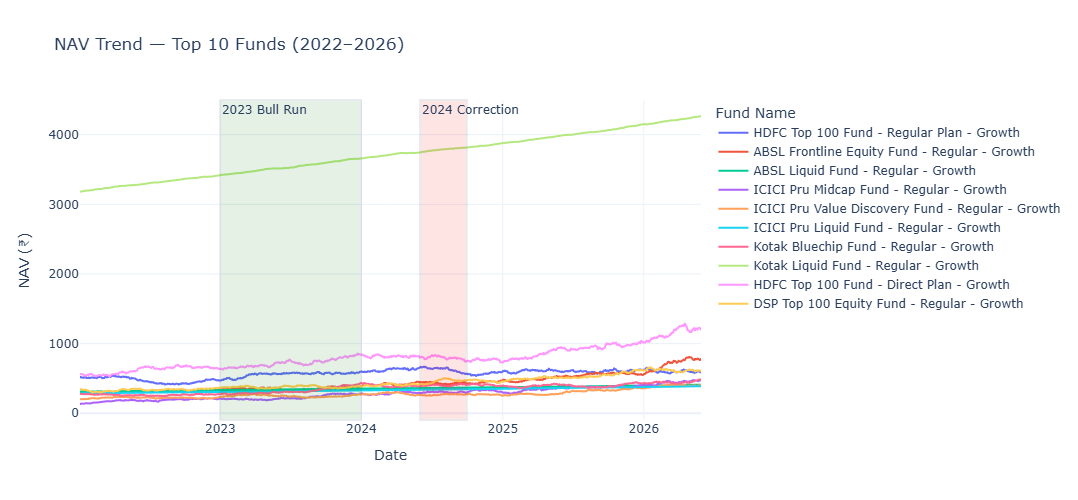

✅ Chart 1 saved → reports/chart1_nav_trend.png


In [5]:
df_nav_merged = df_nav.merge(
    df_fund[["amfi_code", "scheme_name", "fund_house", "category"]],
    on="amfi_code", how="left"
)

top10 = (df_nav_merged.groupby("amfi_code")
         .last()["nav"]
         .nlargest(10)
         .index.tolist())

df_top10 = df_nav_merged[df_nav_merged["amfi_code"].isin(top10)]

fig = px.line(
    df_top10,
    x="date",
    y="nav",
    color="scheme_name",
    title=" NAV Trend — Top 10 Funds (2022–2026)",
    labels={"nav": "NAV (₹)", "date": "Date",
            "scheme_name": "Fund"},
    template="plotly_white"
)

fig.add_vrect(
    x0="2023-01-01", x1="2023-12-31",
    fillcolor="green", opacity=0.1,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

fig.add_vrect(
    x0="2024-06-01", x1="2024-09-30",
    fillcolor="red", opacity=0.1,
    annotation_text="2024 Correction",
    annotation_position="top left"
)

fig.update_layout(height=500, legend_title="Fund Name")
fig.show()

fig.write_image(str(REPORTS / "chart1_nav_trend.png"))
print("✅ Chart 1 saved → reports/chart1_nav_trend.png")

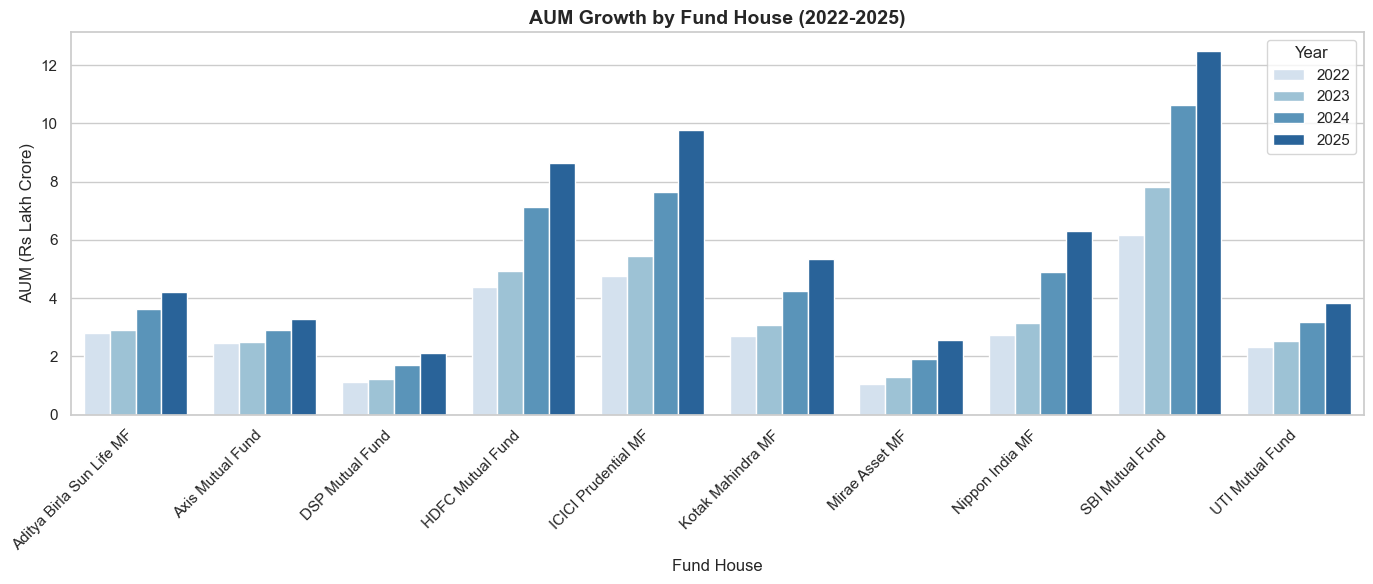

Chart 2 saved


In [9]:
df_aum["date"] = pd.to_datetime(df_aum["date"], errors="coerce")
df_aum["year"] = df_aum["date"].dt.year.astype(str)

df_aum_yr = (df_aum.groupby(["fund_house", "year"])["aum_lakh_crore"].mean().reset_index())

plt.figure(figsize=(14, 6))
sns.barplot(
    data=df_aum_yr,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year",
    palette="Blues"
)
plt.title("AUM Growth by Fund House (2022-2025)", fontsize=14, fontweight="bold")
plt.xlabel("Fund House")
plt.ylabel("AUM (Rs Lakh Crore)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Year", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(REPORTS / "chart2_aum_growth.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 2 saved")

SIP columns: ['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct', 'month_dt']
        month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01-01             11517                       4.91   
1  2022-02-01             11438                       4.93   
2  2022-03-01             12328                       5.09   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct   month_dt  
0                    9.1                4.80          28.295 2022-01-01  
1                    8.2                4.85          28.295 2022-02-01  
2                   10.5                5.01          28.295 2022-03-01  


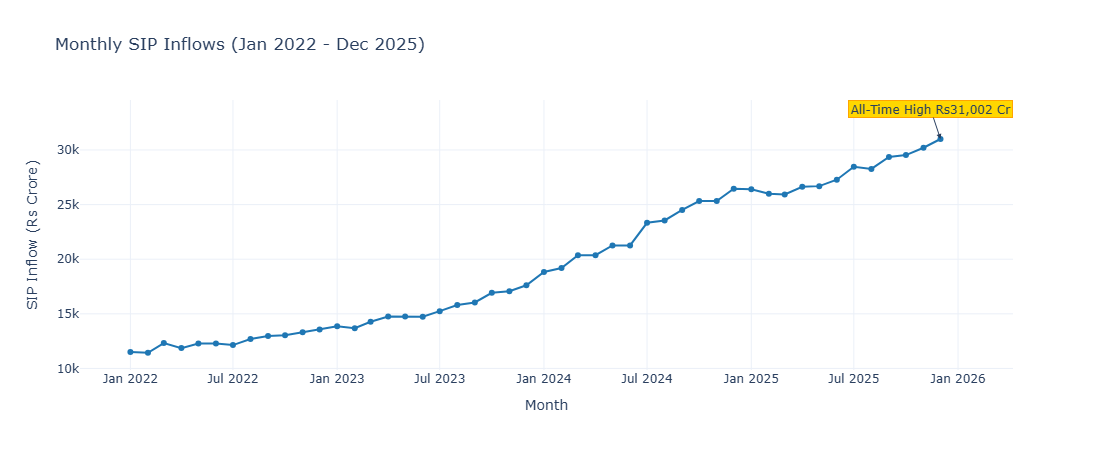

TypeError: Type is not JSON serializable: Timestamp

In [13]:
print("SIP columns:", df_sip.columns.tolist())
print(df_sip.head(3))

df_sip["month_dt"] = pd.to_datetime(df_sip["month"], errors="coerce")
df_sip_sorted = df_sip.sort_values("month_dt")

sip_col = "sip_inflow_crore"

fig = px.line(
    df_sip_sorted,
    x="month_dt",
    y=sip_col,
    title="Monthly SIP Inflows (Jan 2022 - Dec 2025)",
    labels={sip_col: "SIP Inflow (Rs Crore)", "month_dt": "Month"},
    template="plotly_white",
    markers=True
)

max_val = df_sip_sorted[sip_col].max()
max_row = df_sip_sorted[df_sip_sorted[sip_col] == max_val].iloc[0]

fig.add_annotation(
    x=max_row["month_dt"],
    y=max_val,
    text=f"All-Time High Rs{max_val:,.0f} Cr",
    showarrow=True,
    arrowhead=2,
    bgcolor="gold",
    bordercolor="orange"
)

fig.update_traces(line_color="#1f77b4", line_width=2)
fig.update_layout(height=450)
fig.show()
fig.write_image(str(REPORTS / "chart3_sip_inflow.png"))
print("Chart 3 saved")

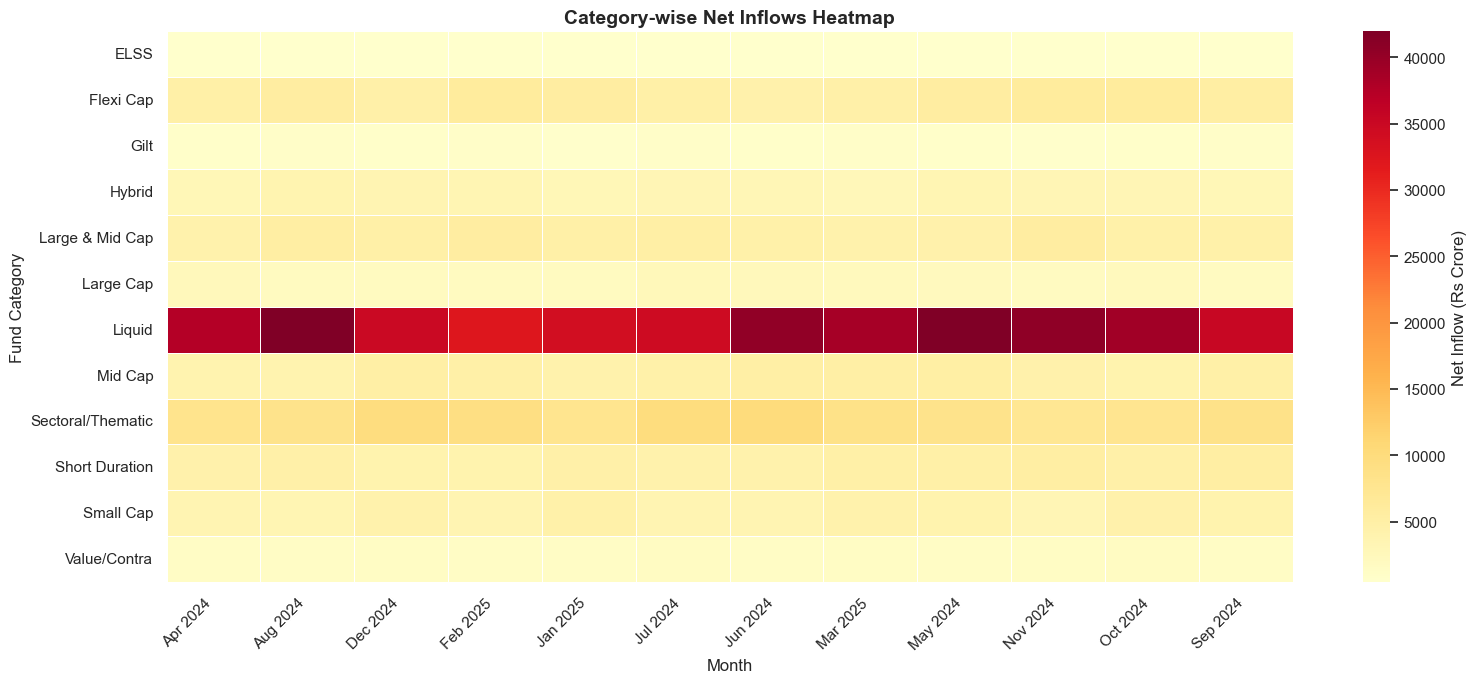

Chart 4 saved


In [16]:
df_cat["month_dt"] = pd.to_datetime(df_cat["month"], errors="coerce")
df_cat["month_str"] = df_cat["month_dt"].dt.strftime("%b %Y")

pivot = df_cat.pivot_table(
    index="category",
    columns="month_str",
    values="net_inflow_crore",
    aggfunc="sum"
)

plt.figure(figsize=(16, 7))
sns.heatmap(
    pivot,
    cmap="YlOrRd",
    linewidths=0.5,
    annot=False,
    cbar_kws={"label": "Net Inflow (Rs Crore)"}
)
plt.title("Category-wise Net Inflows Heatmap", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Fund Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(REPORTS / "chart4_category_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 4 saved")

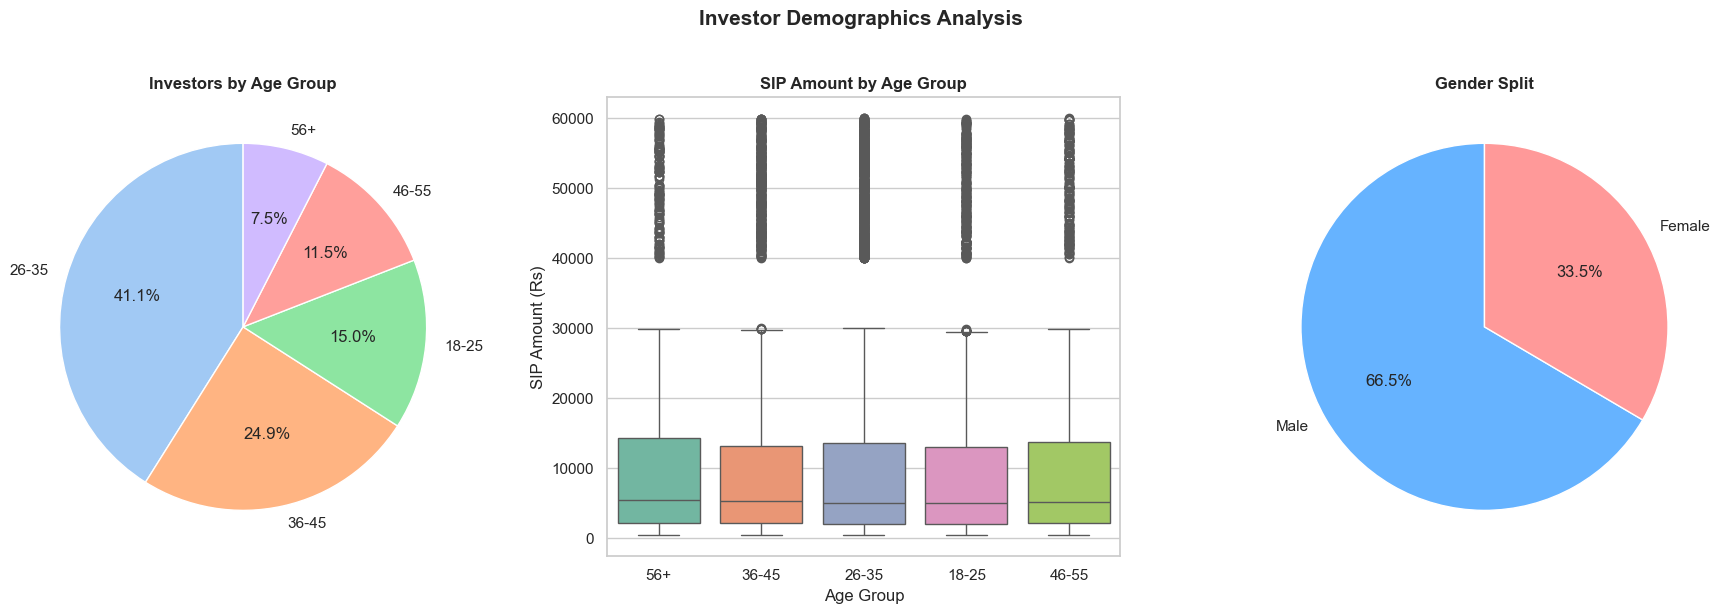

Chart 5 saved


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

age_counts = df_txn["age_group"].value_counts()
axes[0].pie(
    age_counts.values,
    labels=age_counts.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("pastel"),
    startangle=90
)
axes[0].set_title("Investors by Age Group", fontweight="bold")

sip_only = df_txn[df_txn["transaction_type"] == "SIP"]
sns.boxplot(
    data=sip_only,
    x="age_group",
    y="amount_inr",
    palette="Set2",
    ax=axes[1]
)
axes[1].set_title("SIP Amount by Age Group", fontweight="bold")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("SIP Amount (Rs)")

gender_counts = df_txn["gender"].value_counts()
axes[2].pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    colors=["#66b3ff", "#ff9999"],
    startangle=90
)
axes[2].set_title("Gender Split", fontweight="bold")

plt.suptitle("Investor Demographics Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(REPORTS / "chart5_demographics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 5 saved")

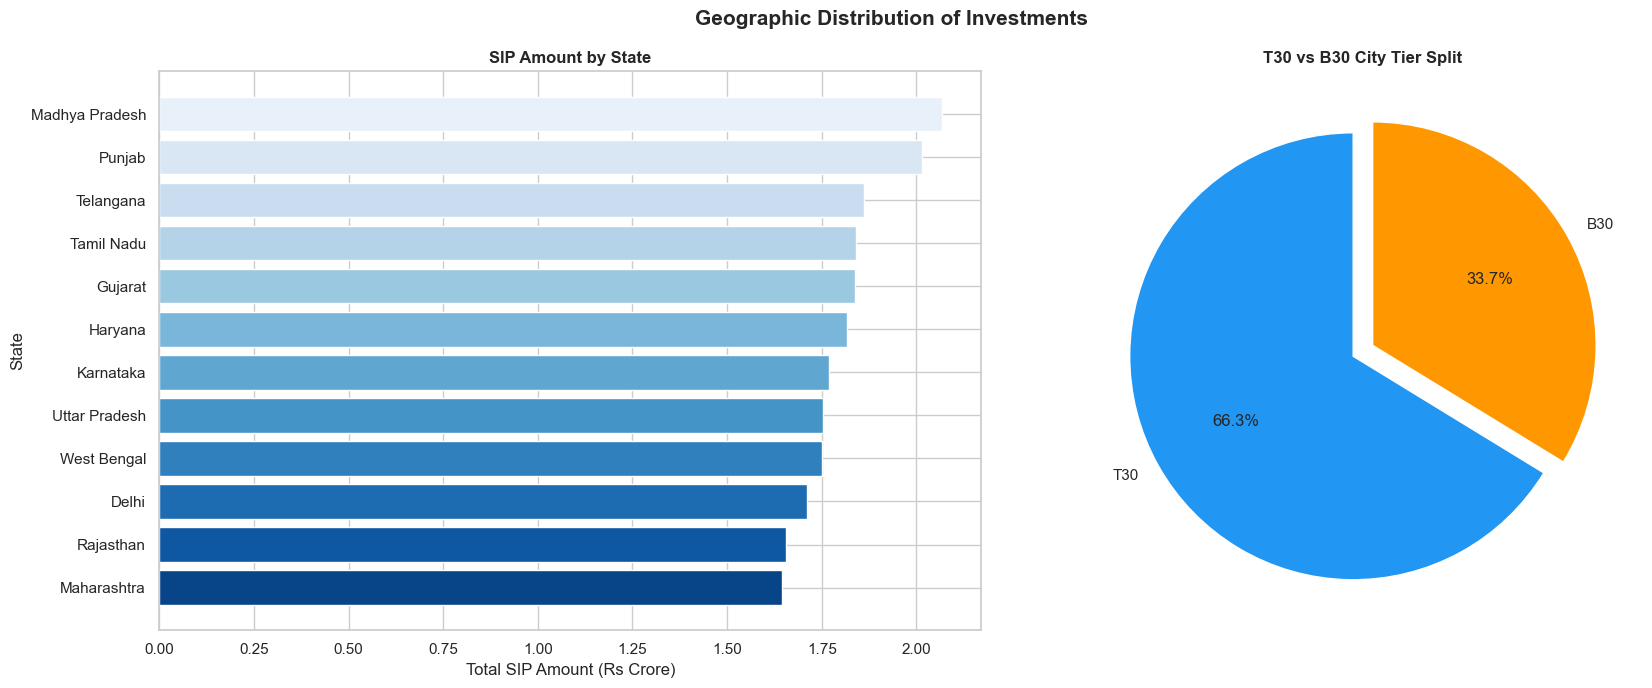

Chart 6 saved


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

state_sip = (df_txn[df_txn["transaction_type"] == "SIP"]
             .groupby("state")["amount_inr"]
             .sum()
             .sort_values(ascending=True))

axes[0].barh(
    state_sip.index,
    state_sip.values / 1e7,
    color=sns.color_palette("Blues_r", len(state_sip))
)
axes[0].set_title("SIP Amount by State", fontweight="bold")
axes[0].set_xlabel("Total SIP Amount (Rs Crore)")
axes[0].set_ylabel("State")

tier_counts = df_txn["city_tier"].value_counts()
axes[1].pie(
    tier_counts.values,
    labels=tier_counts.index,
    autopct="%1.1f%%",
    colors=["#2196F3", "#FF9800"],
    startangle=90,
    explode=[0.05] * len(tier_counts)
)
axes[1].set_title("T30 vs B30 City Tier Split", fontweight="bold")

plt.suptitle("Geographic Distribution of Investments", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS / "chart6_geographic.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 6 saved")

Folio columns: ['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
        month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01-01               13.26                 9.28               1.86   
1  2022-04-01               13.91                 9.74               1.95   
2  2022-07-01               13.85                 9.69               1.94   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  


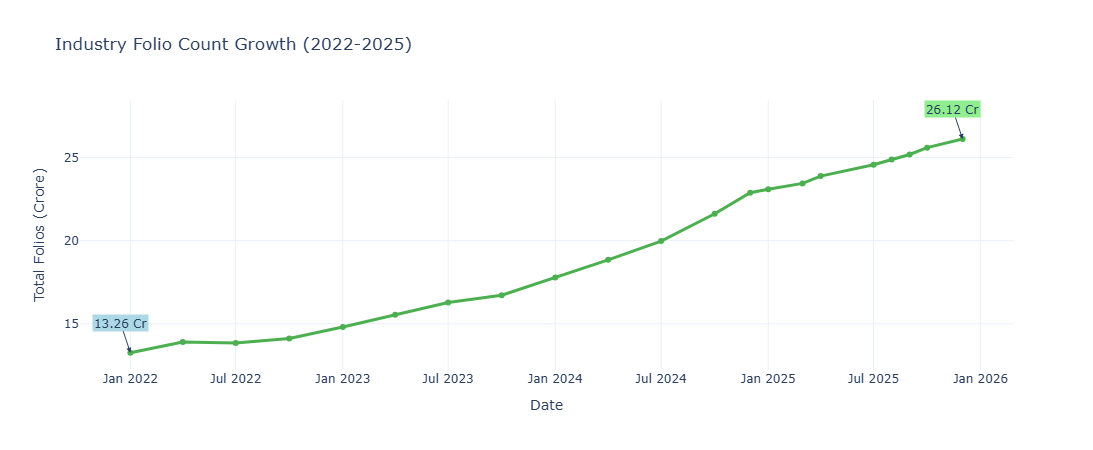

Chart 7 saved


In [19]:
print("Folio columns:", df_folio.columns.tolist())
print(df_folio.head(3))

date_col = df_folio.columns[0]
total_col = [c for c in df_folio.columns if "total" in c.lower() or "folio" in c.lower()][0]

df_folio["date_dt"] = pd.to_datetime(df_folio[date_col], errors="coerce")
df_folio_sorted = df_folio.sort_values("date_dt")

fig = px.line(
    df_folio_sorted,
    x="date_dt",
    y=total_col,
    title="Industry Folio Count Growth (2022-2025)",
    labels={total_col: "Total Folios (Crore)", "date_dt": "Date"},
    template="plotly_white",
    markers=True
)

fig.add_annotation(x="2022-01-01", y=13.26, text="13.26 Cr", showarrow=True, arrowhead=2, bgcolor="lightblue")
fig.add_annotation(x="2025-12-01", y=26.12, text="26.12 Cr", showarrow=True, arrowhead=2, bgcolor="lightgreen")

fig.update_traces(line_color="#4CAF50", line_width=3)
fig.update_layout(height=450)
fig.show()
fig.write_image(str(REPORTS / "chart7_folio_growth.png"))
print("Chart 7 saved")

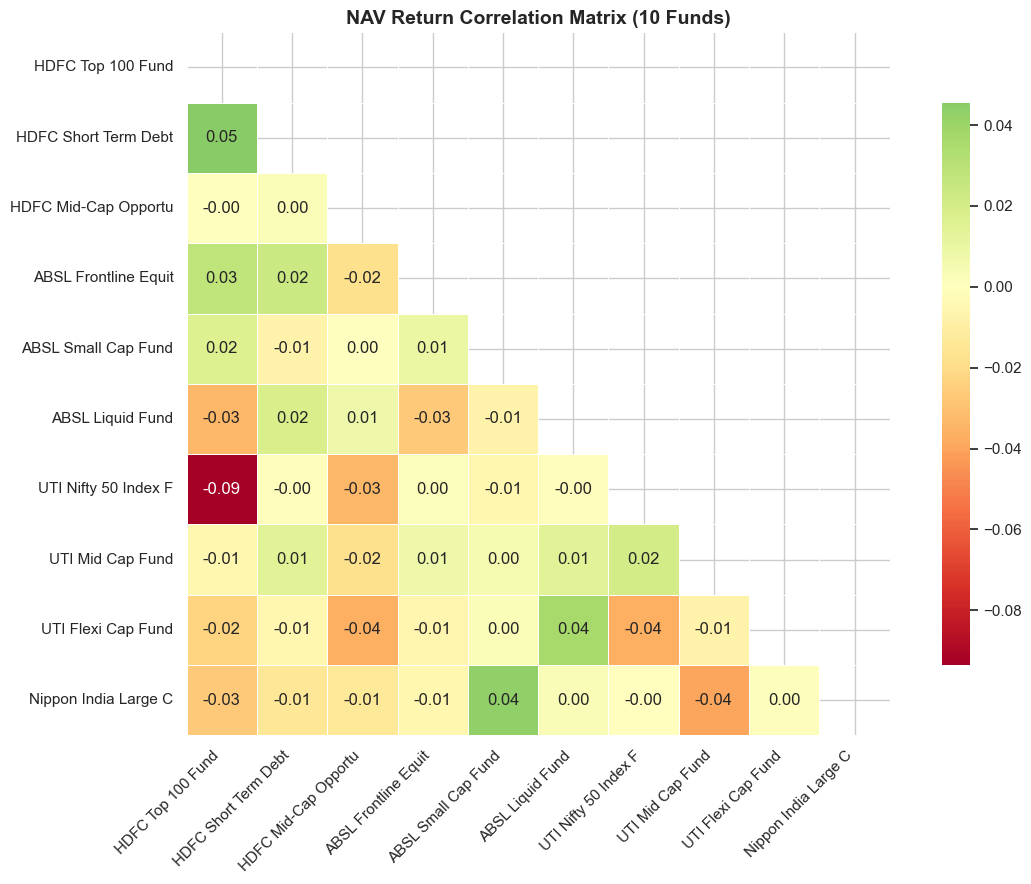

Chart 8 saved


In [20]:
top10_codes = (df_nav.groupby("amfi_code")["nav"].count().nlargest(10).index.tolist())

pivot_ret = (df_nav[df_nav["amfi_code"].isin(top10_codes)]
             .pivot_table(index="date", columns="amfi_code", values="daily_return_pct"))

code_name = (df_fund.set_index("amfi_code")["scheme_name"]
             .str.split(" - ").str[0].str[:20])

pivot_ret.columns = [code_name.get(c, str(c)) for c in pivot_ret.columns]

corr_matrix = pivot_ret.corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("NAV Return Correlation Matrix (10 Funds)", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(REPORTS / "chart8_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 8 saved")

Portfolio columns: ['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']
   amfi_code stock_symbol              stock_name       sector  weight_pct  \
0     119551    POWERGRID  Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK           HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM   Grasim Industries Ltd  Diversified        9.90   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  


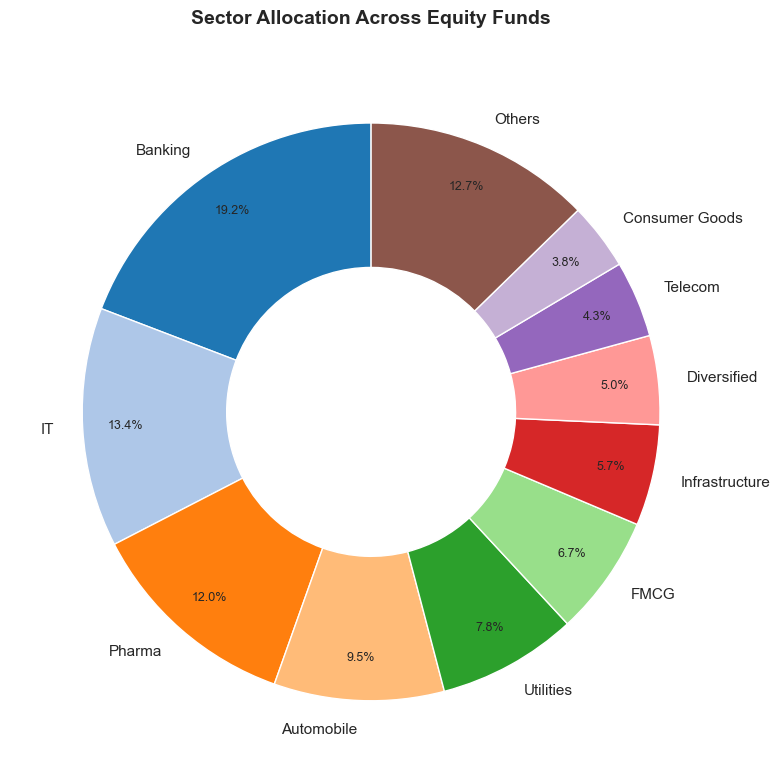

Chart 9 saved


In [21]:
print("Portfolio columns:", df_port.columns.tolist())
print(df_port.head(3))

sector_col = [c for c in df_port.columns if "sector" in c.lower()][0]
weight_col = [c for c in df_port.columns if "weight" in c.lower()][0]

sector_agg = (df_port.groupby(sector_col)[weight_col].sum().sort_values(ascending=False))

top_sectors = sector_agg.head(10)
others = sector_agg.iloc[10:].sum()
if others > 0:
    top_sectors["Others"] = others

fig, ax = plt.subplots(figsize=(12, 8))
colors = sns.color_palette("tab20", len(top_sectors))

wedges, texts, autotexts = ax.pie(
    top_sectors.values,
    labels=top_sectors.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    pctdistance=0.85,
    wedgeprops=dict(width=0.5)
)

for text in autotexts:
    text.set_fontsize(9)

ax.set_title("Sector Allocation Across Equity Funds", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig(REPORTS / "chart9_sector_donut.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 9 saved")

In [23]:
findings = """
EDA Key Findings - Bluestock MF Capstone

10 Key Insights

Finding 1 - NAV Trend:
Most equity funds showed strong upward trend during 2023 bull run
with average NAV growth of 25-30%, followed by mild correction in mid-2024.

Finding 2 - AUM Dominance:
SBI Mutual Fund leads with highest AUM among all fund houses,
consistent with AMFI data showing SBI at Rs 12.5 Lakh Crore as of Dec 2025.

Finding 3 - SIP Growth:
Monthly SIP inflows grew consistently from 2022 reaching an all-time
high of Rs 31,002 Crore in December 2025.

Finding 4 - Category Inflows:
Large Cap and Flexi Cap categories received highest inflows consistently,
while Small Cap saw surge during 2023 bull market.

Finding 5 - Age Demographics:
Investors aged 26-35 form the largest investor group showing that
young working professionals are the primary mutual fund investors.

Finding 6 - Geographic Distribution:
Maharashtra, Karnataka and Tamil Nadu lead in SIP investments,
while T30 cities account for majority of transactions.

Finding 7 - Folio Growth:
Total investor folios nearly doubled from 13.26 Crore in January 2022
to 26.12 Crore in December 2025.

Finding 8 - Fund Correlation:
Large Cap funds from different AMCs show high correlation above 0.85,
suggesting similar portfolio composition.

Finding 9 - Sector Allocation:
Financial Services and IT sectors have highest allocation across
equity mutual funds followed by Healthcare and FMCG.

Finding 10 - Gender Split:
Male investors dominate mutual fund investments at approximately 65%
but female investor participation is growing steadily.
"""

findings_path = REPORTS / "EDA_Findings.md"
findings_path.write_text(findings)
print(findings)
print(f"EDA Findings saved to {findings_path}")


EDA Key Findings - Bluestock MF Capstone

10 Key Insights

Finding 1 - NAV Trend:
Most equity funds showed strong upward trend during 2023 bull run
with average NAV growth of 25-30%, followed by mild correction in mid-2024.

Finding 2 - AUM Dominance:
SBI Mutual Fund leads with highest AUM among all fund houses,
consistent with AMFI data showing SBI at Rs 12.5 Lakh Crore as of Dec 2025.

Finding 3 - SIP Growth:
Monthly SIP inflows grew consistently from 2022 reaching an all-time
high of Rs 31,002 Crore in December 2025.

Finding 4 - Category Inflows:
Large Cap and Flexi Cap categories received highest inflows consistently,
while Small Cap saw surge during 2023 bull market.

Finding 5 - Age Demographics:
Investors aged 26-35 form the largest investor group showing that
young working professionals are the primary mutual fund investors.

Finding 6 - Geographic Distribution:
Maharashtra, Karnataka and Tamil Nadu lead in SIP investments,
while T30 cities account for majority of transaction

In [24]:
print("DAY 3 COMPLETE")

charts = list(REPORTS.glob("chart*.png"))
print(f"Charts saved: {len(charts)}")
for chart in sorted(charts):
    print(f"  {chart.name}")

print(f"nav_history : {df_nav.shape[0]:,} rows")
print(f"investor_transactions : {df_txn.shape[0]:,} rows")
print(f"portfolio_holdings : {df_port.shape[0]:,} rows")
print(f"monthly_sip_inflows : {df_sip.shape[0]:,} rows")
print("Next - Day 4: Performance Analytics!")

DAY 3 COMPLETE
Charts saved: 8
  chart1_nav_trend.png
  chart2_aum_growth.png
  chart4_category_heatmap.png
  chart5_demographics.png
  chart6_geographic.png
  chart7_folio_growth.png
  chart8_correlation.png
  chart9_sector_donut.png
nav_history : 46,000 rows
investor_transactions : 32,778 rows
portfolio_holdings : 322 rows
monthly_sip_inflows : 48 rows
Next - Day 4: Performance Analytics!


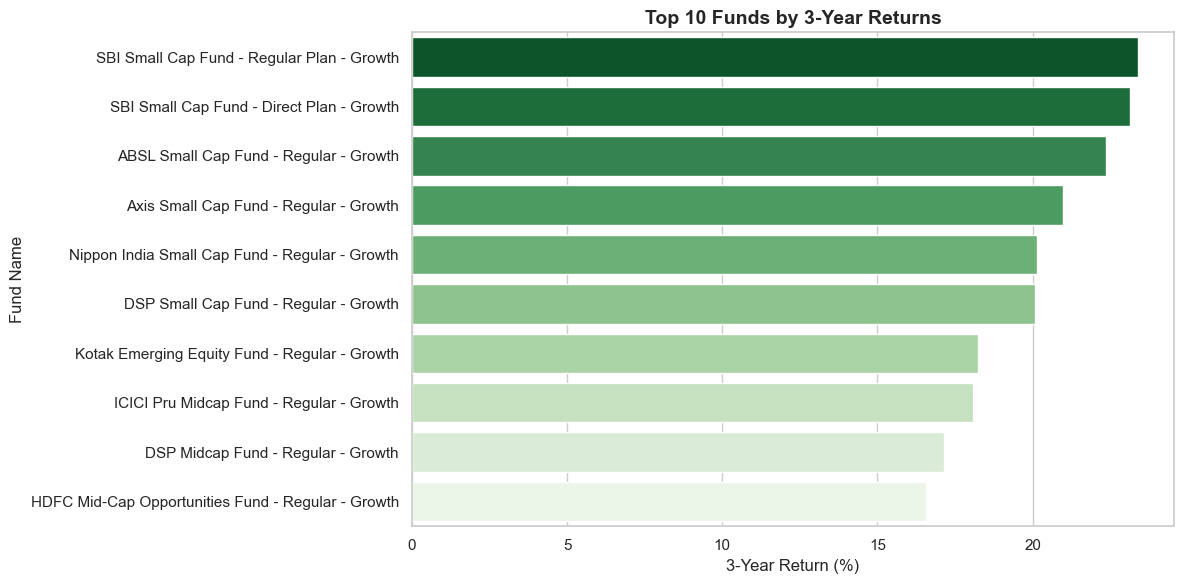

Chart 10 saved


In [25]:
df_perf = pd.read_csv(PROCESSED / "clean_scheme_performance.csv")

top_returns = df_perf.nlargest(10, "return_3yr_pct")[["scheme_name", "return_3yr_pct"]]

plt.figure(figsize=(12, 6))
sns.barplot(data=top_returns, x="return_3yr_pct", y="scheme_name", palette="Greens_r")
plt.title("Top 10 Funds by 3-Year Returns", fontsize=14, fontweight="bold")
plt.xlabel("3-Year Return (%)")
plt.ylabel("Fund Name")
plt.tight_layout()
plt.savefig(REPORTS / "chart10_top_returns.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 10 saved")

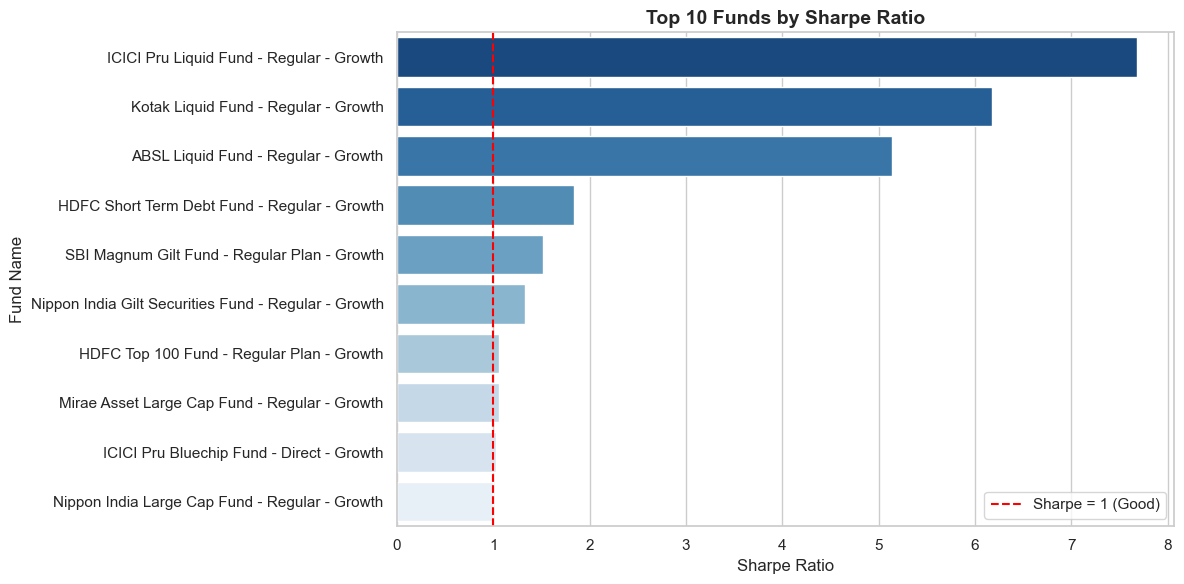

Chart 11 saved


In [26]:
top_sharpe = df_perf.nlargest(10, "sharpe_ratio")[["scheme_name", "sharpe_ratio"]]

plt.figure(figsize=(12, 6))
sns.barplot(data=top_sharpe, x="sharpe_ratio", y="scheme_name", palette="Blues_r")
plt.title("Top 10 Funds by Sharpe Ratio", fontsize=14, fontweight="bold")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Fund Name")
plt.axvline(x=1, color="red", linestyle="--", label="Sharpe = 1 (Good)")
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS / "chart11_sharpe_ratio.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 11 saved")

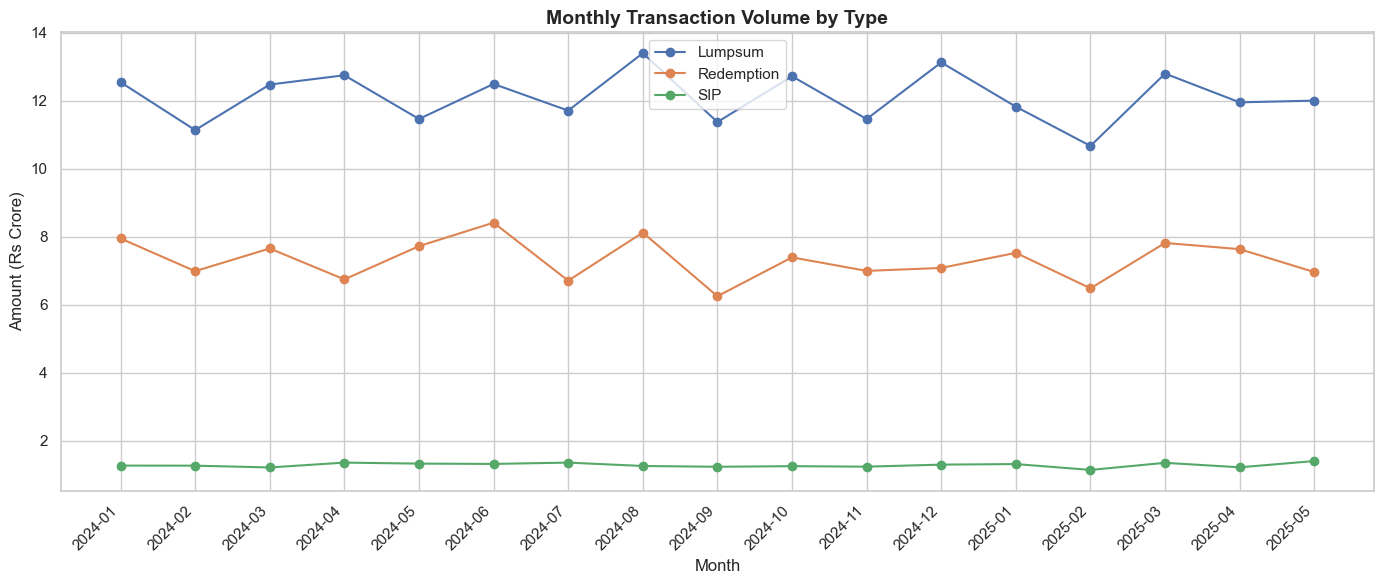

Chart 12 saved


In [27]:
df_txn["month"] = df_txn["transaction_date"].dt.to_period("M").astype(str)
monthly_txn = df_txn.groupby(["month", "transaction_type"])["amount_inr"].sum().reset_index()

plt.figure(figsize=(14, 6))
for txn_type in monthly_txn["transaction_type"].unique():
    data = monthly_txn[monthly_txn["transaction_type"] == txn_type]
    plt.plot(data["month"], data["amount_inr"] / 1e7, label=txn_type, marker="o")

plt.title("Monthly Transaction Volume by Type", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Amount (Rs Crore)")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS / "chart12_monthly_transactions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 12 saved")

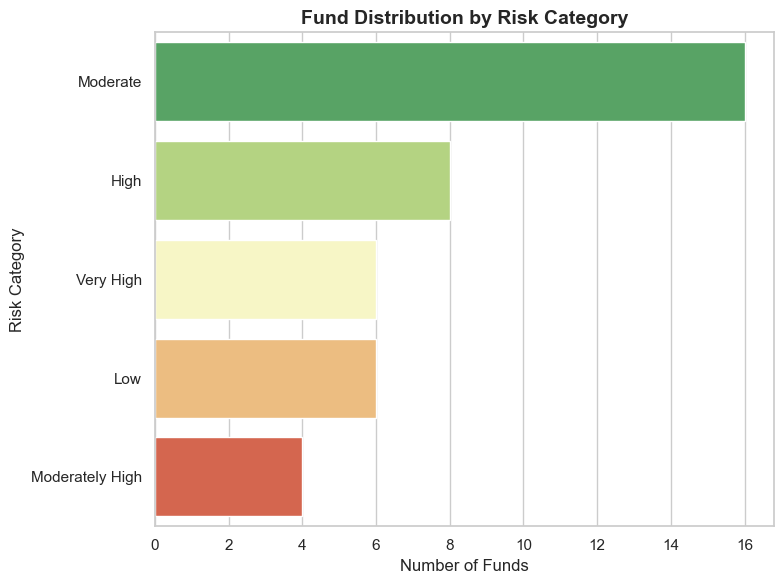

Chart 13 saved


In [28]:
risk_dist = df_fund["risk_category"].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=risk_dist.values, y=risk_dist.index, palette="RdYlGn_r")
plt.title("Fund Distribution by Risk Category", fontsize=14, fontweight="bold")
plt.xlabel("Number of Funds")
plt.ylabel("Risk Category")
plt.tight_layout()
plt.savefig(REPORTS / "chart13_risk_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 13 saved")

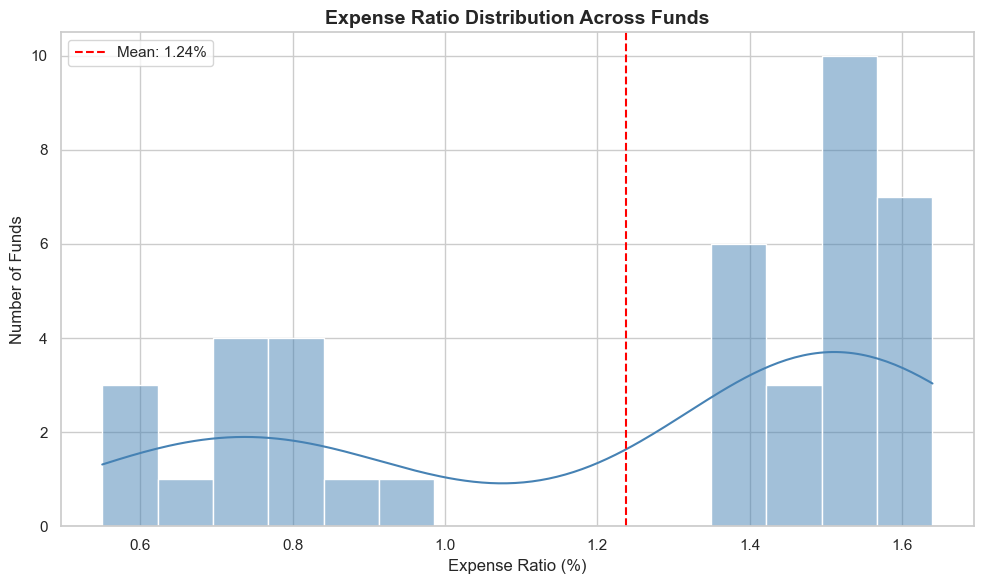

Chart 14 saved


In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(df_fund["expense_ratio_pct"], bins=15, kde=True, color="steelblue")
plt.title("Expense Ratio Distribution Across Funds", fontsize=14, fontweight="bold")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Number of Funds")
plt.axvline(x=df_fund["expense_ratio_pct"].mean(), color="red",
            linestyle="--", label=f"Mean: {df_fund['expense_ratio_pct'].mean():.2f}%")
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS / "chart14_expense_ratio.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 14 saved")

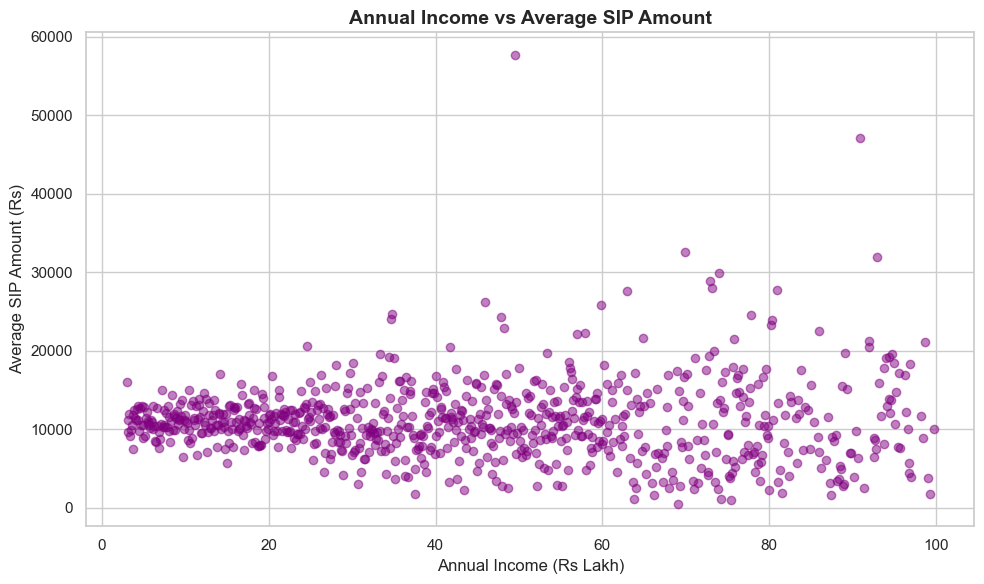

Chart 15 saved


In [30]:
income_sip = (df_txn[df_txn["transaction_type"] == "SIP"]
              .groupby("annual_income_lakh")["amount_inr"]
              .mean().reset_index())

plt.figure(figsize=(10, 6))
plt.scatter(income_sip["annual_income_lakh"],
            income_sip["amount_inr"],
            alpha=0.5, color="purple")
plt.title("Annual Income vs Average SIP Amount", fontsize=14, fontweight="bold")
plt.xlabel("Annual Income (Rs Lakh)")
plt.ylabel("Average SIP Amount (Rs)")
plt.tight_layout()
plt.savefig(REPORTS / "chart15_income_sip.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 15 saved")

In [31]:
charts = list(REPORTS.glob("chart*.png"))
print(f"Total charts saved: {len(charts)}")
for chart in sorted(charts):
    print(f"  {chart.name}")
print("Day 3 Complete!")

Total charts saved: 14
  chart10_top_returns.png
  chart11_sharpe_ratio.png
  chart12_monthly_transactions.png
  chart13_risk_distribution.png
  chart14_expense_ratio.png
  chart15_income_sip.png
  chart1_nav_trend.png
  chart2_aum_growth.png
  chart4_category_heatmap.png
  chart5_demographics.png
  chart6_geographic.png
  chart7_folio_growth.png
  chart8_correlation.png
  chart9_sector_donut.png
Day 3 Complete!
